In [23]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from imblearn.combine import SMOTETomek
from sklearn.metrics import recall_score, f1_score, precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


In [24]:
data_path = "sleep_doomscrolling_habits.csv"

df = pd.read_csv(data_path)

df.head(10)

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,...,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,...,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,...,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,...,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,...,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair
5,D30005,21,81.0,5.20,4,19.5,7.9,39.0,2,61.0,...,Student,Nigeria,Smartphone,Watching Videos,No,Yes,No,No,Yes,Fair
6,D30006,34,56.0,3.75,3,18.7,8.8,45.0,1,166.0,...,Employed Full-time,Philippines,Smartphone,Scrolling Social Media,No,Yes,No,No,Yes,Good
7,D30007,26,40.0,2.41,3,13.7,7.7,36.0,2,54.0,...,Student,United Kingdom,Smartphone,Scrolling Social Media,Yes,Yes,Yes,Yes,Yes,Poor
8,D30008,32,77.0,3.38,4,19.2,7.8,29.0,1,127.0,...,Employed Full-time,Germany,Smartphone,Reading,Yes,Yes,No,No,Yes,Fair
9,D30009,34,23.0,2.46,2,7.8,6.4,18.0,3,97.0,...,Employed Full-time,Philippines,Tablet,Reading,No,No,No,No,No,Poor


In [25]:
# Reading null data
print(f"Missing Values : {df.isnull().sum()}")

Missing Values : respondent_id                      0
age                                0
bedtime_screen_time_minutes        0
total_daily_screen_time_hours      0
doomscroll_sessions_per_night      0
avg_doomscroll_session_minutes     0
sleep_hours_per_night              0
sleep_latency_minutes              0
number_of_night_wakeups            0
caffeine_intake_mg_per_day        50
anxiety_score                      0
stress_score                       0
sleep_quality_score               40
daytime_fatigue_score              0
number_of_news_apps_used           0
phone_checks_per_night             0
exercise_minutes_per_day          50
days_since_last_digital_detox      0
weekly_sleep_debt_hours            0
gender                             0
occupation_status                 30
country_region                     0
primary_device_used_at_night      30
bedtime_routine_type              20
uses_night_mode                    0
keeps_phone_in_bedroom             0
consumes_negative_new

In [26]:
print(df['bedtime_routine_type'].unique())

<StringArray>
[ 'Meditation/Journaling',                'Reading',       'No Fixed Routine',
        'Watching Videos', 'Scrolling Social Media',                      nan]
Length: 6, dtype: str


In [27]:
dfe = df.copy()

dfe = dfe.drop(['respondent_id'], axis=1)

cat_cols = ['caffeine_intake_mg_per_day', 'sleep_quality_score', 'exercise_minutes_per_day', 'occupation_status', 'primary_device_used_at_night', 'bedtime_routine_type']  

cat_imputer = SimpleImputer(strategy='most_frequent')
dfe[cat_cols] = cat_imputer.fit_transform(dfe[cat_cols])

print(f"Missing Values : {dfe.isnull().sum().max()}")

Missing Values : 0


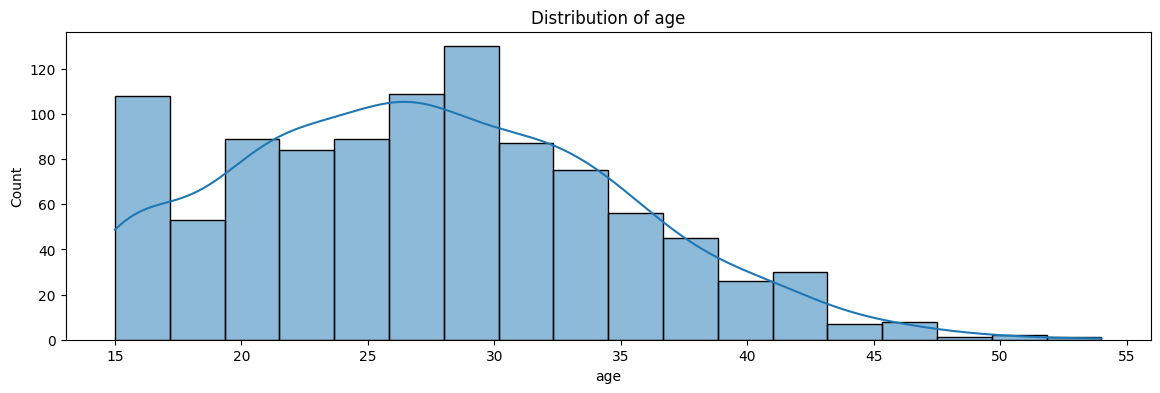

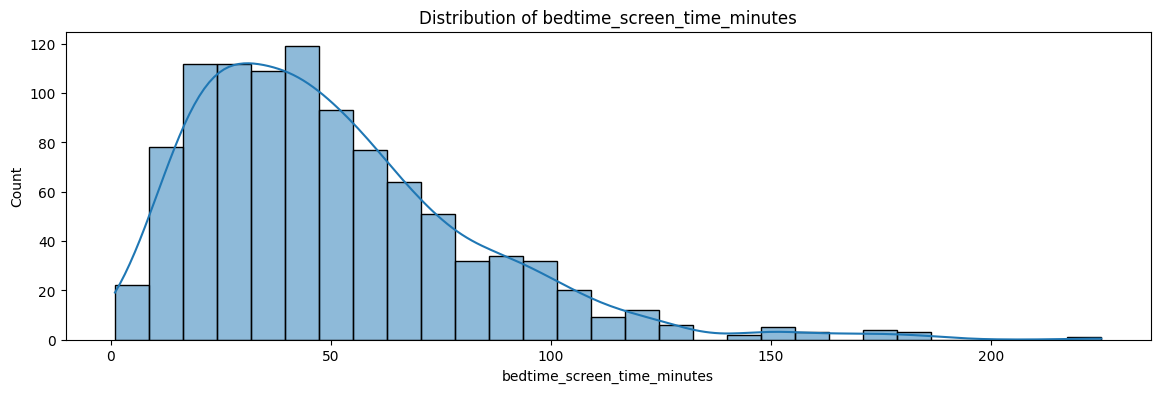

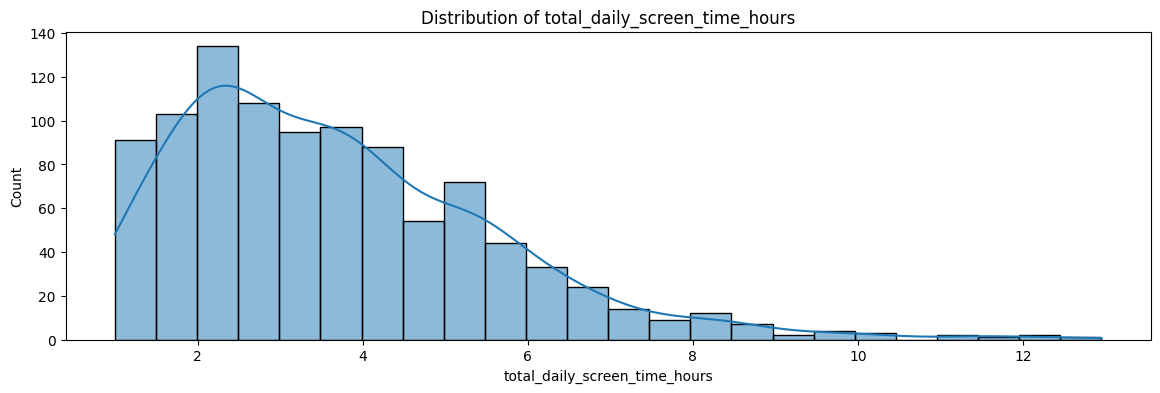

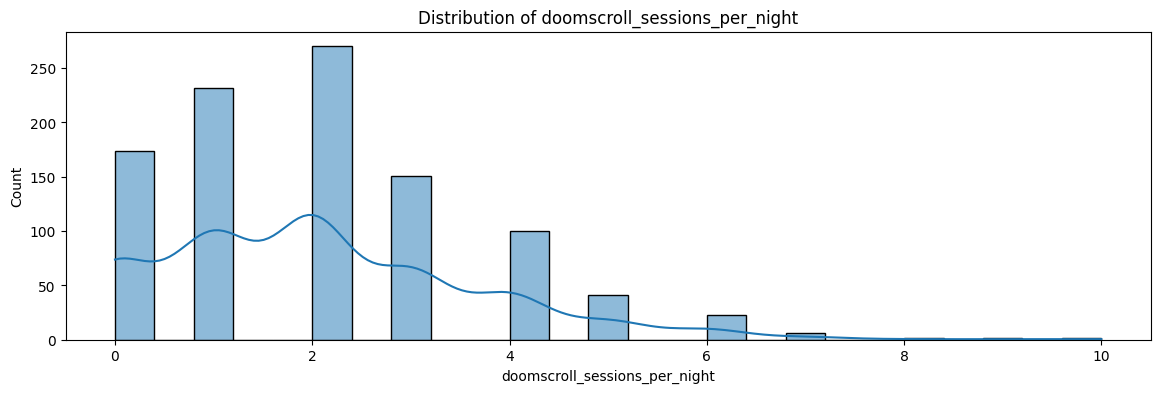

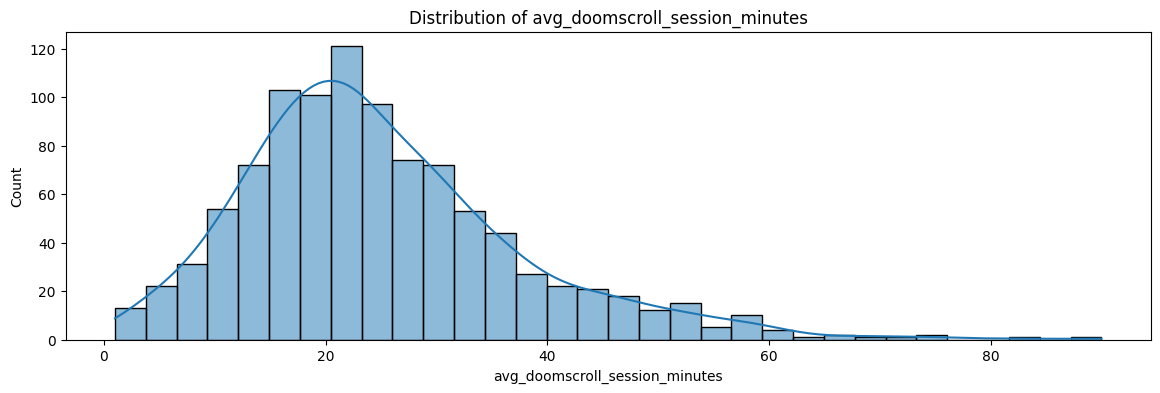

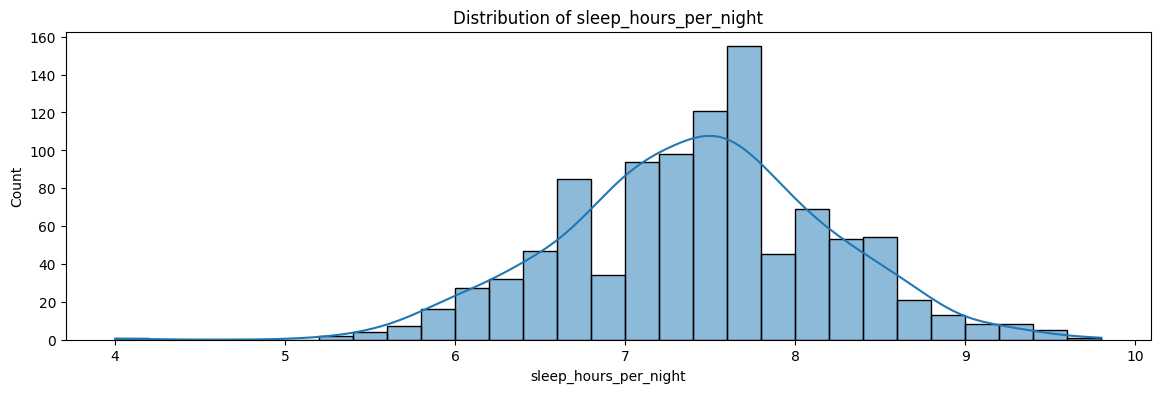

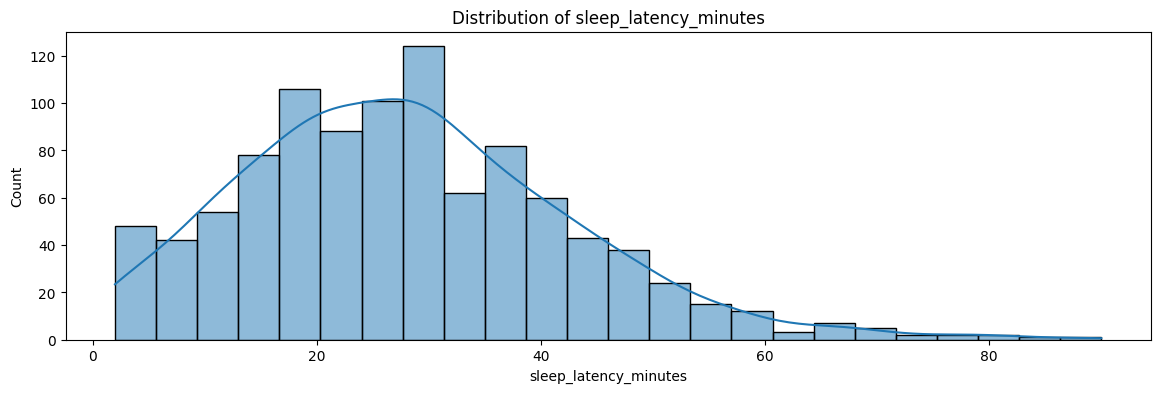

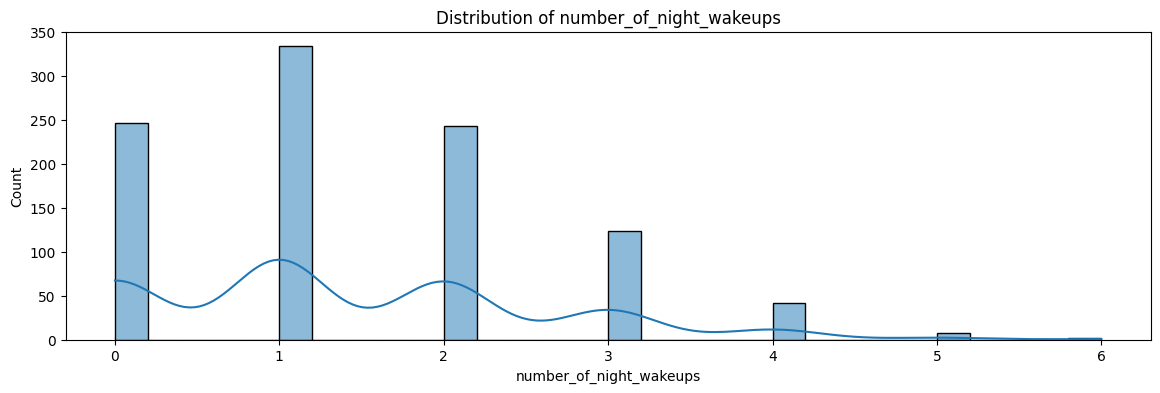

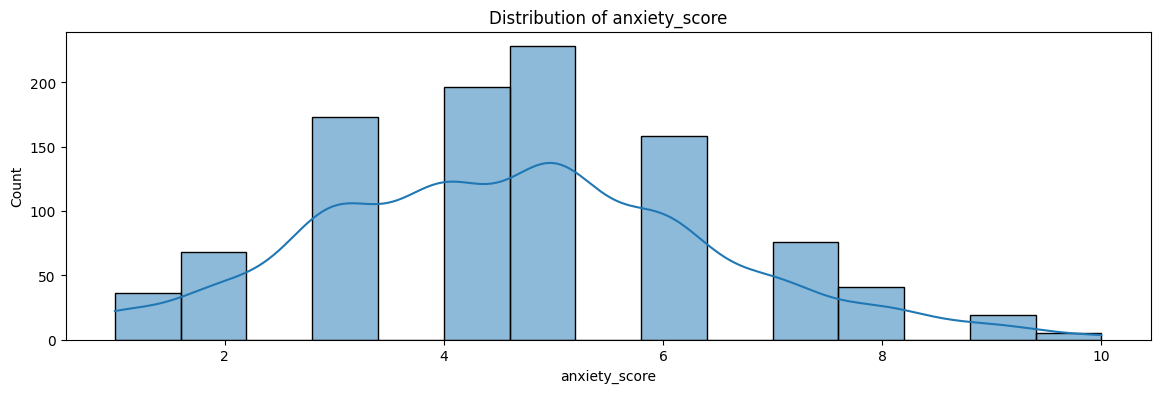

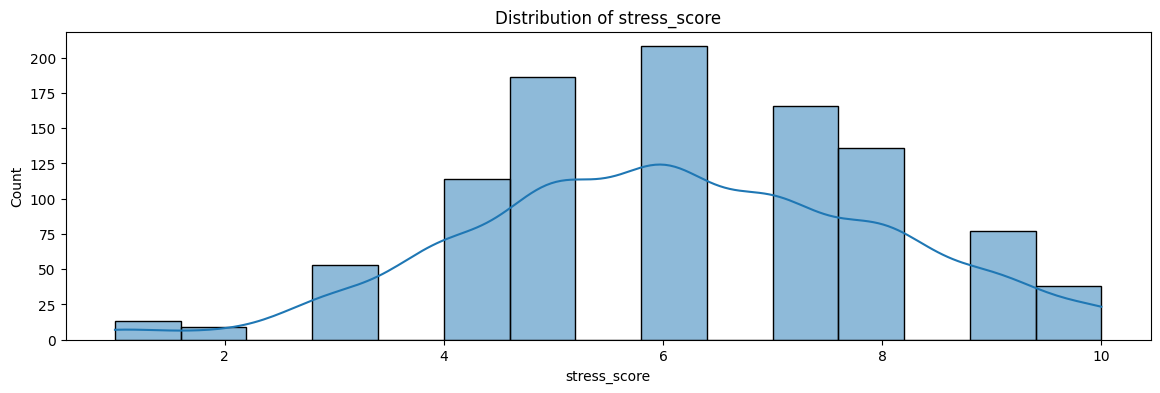

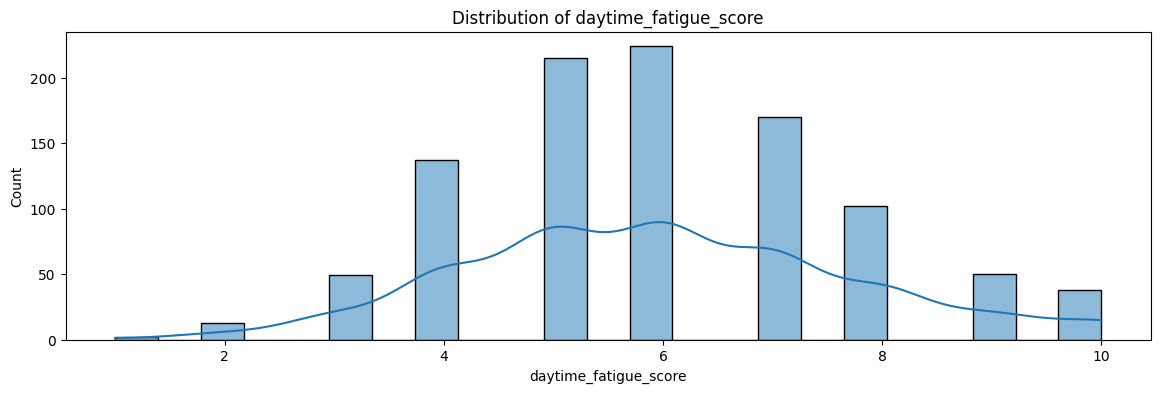

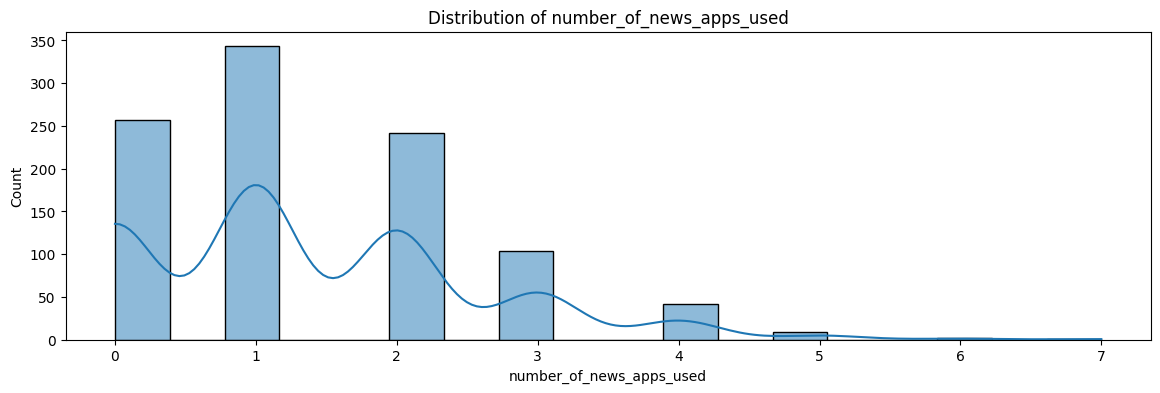

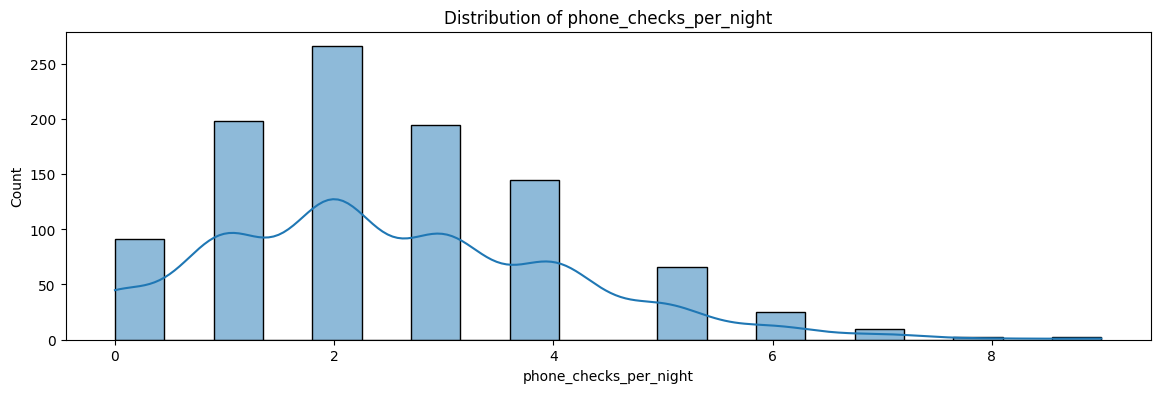

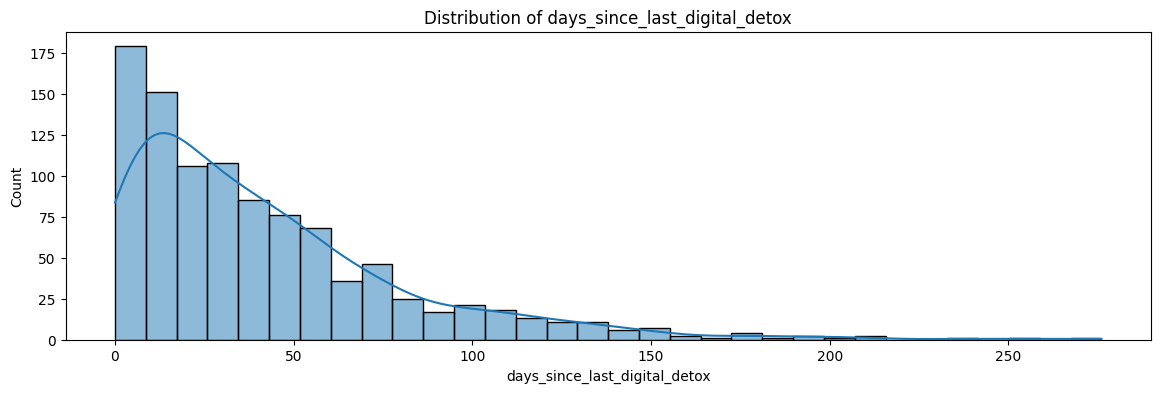

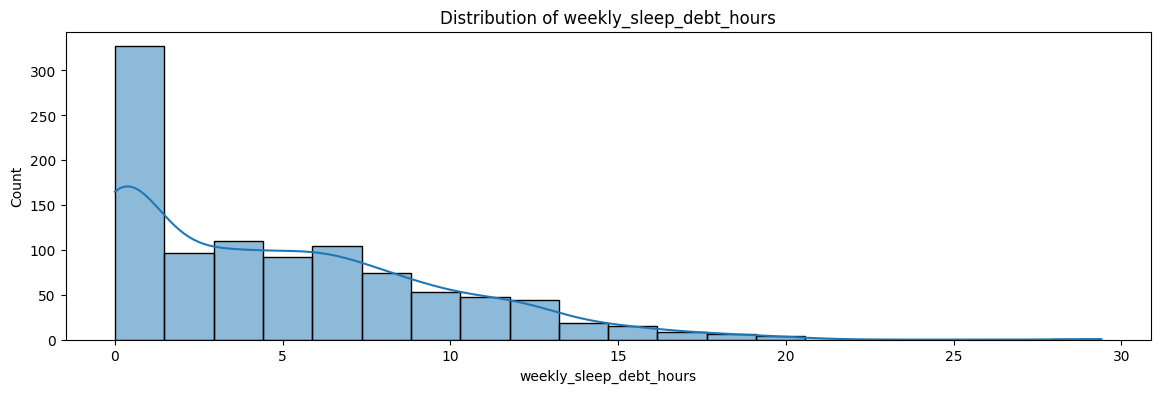

In [ ]:
# EDA Data visualization for types of number

num_cols=dfe.select_dtypes(include='number')
for col in num_cols[:10]:
    plt.figure(figsize=(14,4))
    sns.histplot(dfe[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
    